In [1]:
import numpy as np
from tncdr.stabilizer_mps.tensor_network import TensorNetwork

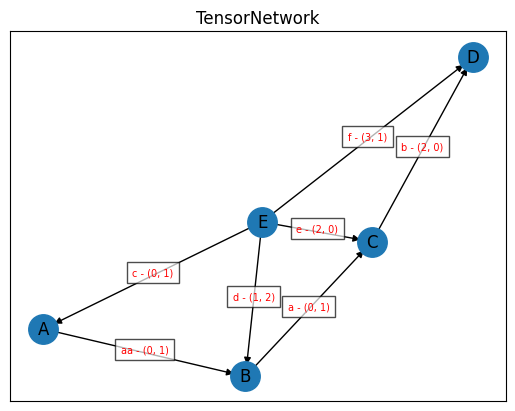

[('A', 'Z', 'aa', {'directions': (0, 0)}), ('E', 'Z', 'd', {'directions': (1, 1)}), ('E', 'Z', 'e', {'directions': (2, 2)})]


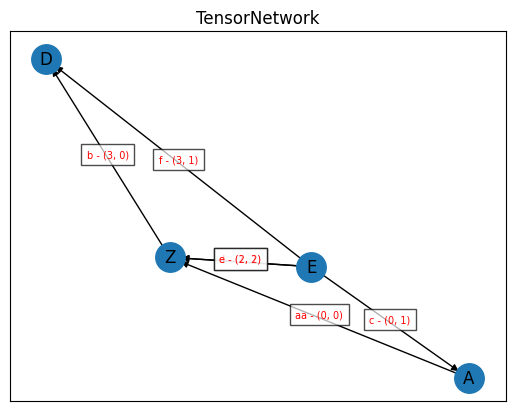

In [2]:
tn = TensorNetwork()
tn.add_tensor(id='A', tensor=np.random.rand(4,3,3))
tn.add_tensor(id='B', tensor=np.random.rand(3,4,6))
tn.add_tensor(id='C', tensor=np.random.rand(4,3,3))
tn.add_tensor(id='D', tensor=np.random.rand(3,4,6))
tn.add_tensor(id='E', tensor=np.random.rand(3,6,4,4))

tn.add_edge(
    node_in='A',
    node_out='B',
    edge_id='aa',
    directions=(0,1),
    comment='metadata',
)

tn.add_edge(
    node_in='B',
    node_out='C',
    edge_id='a',
    directions=(0,1),
    comment='metadata',
)

tn.add_edge(
    node_in='C',
    node_out='D',
    edge_id='b',
    directions=(2,0),
    comment='metadata',
)

tn.add_edge(
    node_in='E',
    node_out='A',
    edge_id='c',
    directions=(0,1),
    comment='metadata',
)

tn.add_edge(
    node_in='E',
    node_out='B',
    edge_id='d',
    directions=(1,2),
    comment='metadata',
)

tn.add_edge(
    node_in='E',
    node_out='C',
    edge_id='e',
    directions=(2,0),
    comment='metadata',
)

tn.add_edge(
    node_in='E',
    node_out='D',
    edge_id='f',
    directions=(3,1),
    comment='metadata',
)

tn.draw()
tn.contract('B','C','a', 'Z')
print(tn.tensornet.in_edges('Z', keys=True, data=True))
tn.draw()

In [3]:
ghz = TensorNetwork()
N = 5

A0 = np.array([[1,0],[0,0]])
A1 = np.array([[0,0],[0,1]])
tensor = ((0.5)**(0.5/N))*np.array([A0, A1])

for n in range(N):
    ghz.add_measurement(id=f'M{n}', alpha=0.0, beta=1.0)    
    ghz.add_tensor(id=f'T{n}', tensor=tensor)
    ghz.add_edge(f'M{n}', f'T{n}', f'p{n}', (0,0))

for n in range(N):
    n1, n2 = n%N, (n+1)%N
    ghz.add_edge(f'T{n1}',f'T{n2}', f'X{n1}->{n2}', (1,2))

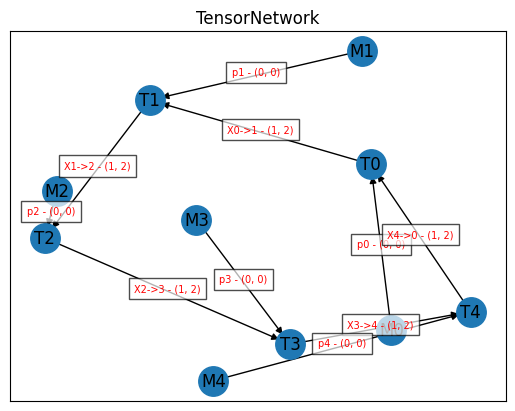

In [4]:
ghz.draw()

In [5]:
# |<0|GHZ>|^2 -> sqrt(1/2)
theoretical = np.sqrt(0.5)
theoretical

0.7071067811865476

In [6]:
# Contract the network

ghz.contract(f'M0', f'T0', f'p0', f'C0')
for n in range(N-1):
    ghz.contract(f'C{n}', f'T{n+1}', f'X{n}->{n+1}', f'tmp')
    ghz.contract(f'M{n+1}', f'tmp', f'p{n+1}', f'C{n+1}')

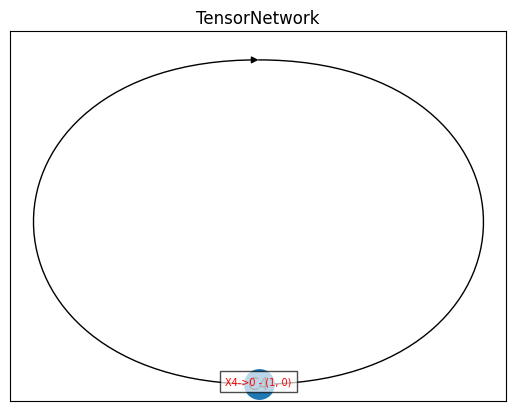

In [7]:
ghz.draw()

In [8]:
ghz.contract(f'C{N-1}', f'C{N-1}', f'X{N-1}->0', f'F')

NetworkXError: The node C4 is not in the digraph.

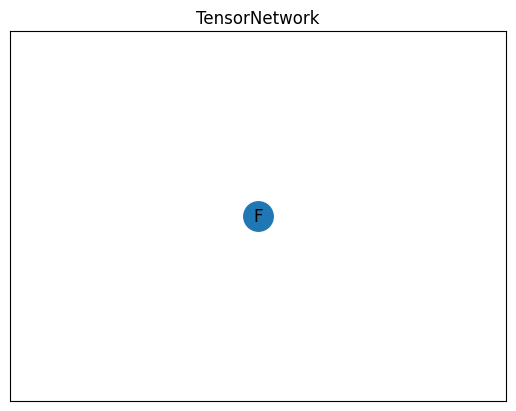

In [9]:
ghz.draw()

In [10]:
ghz.tensornet.nodes['F']

{'tensor': array([[0. , 0. ],
        [0. , 0.5]]),
 'shape': (2, 2),
 'free_directions': [True, True]}